# Grayscale Image Converter and Black Content Analyzer

This notebook:
1. Converts all images in a directory to grayscale
2. Saves them to a new directory with "grayscale_" prefix
3. Calculates mean grayscale values for all images
4. Filters images with higher black content (lower mean values = more black)

In [60]:
import os
import cv2
import numpy as np
from pathlib import Path
import shutil

## Step 1: Convert Images to Grayscale

In [61]:
def convert_to_grayscale(input_dir):
    """
    Convert all images in input_dir to grayscale and save to a new directory.
    
    Args:
        input_dir: Path to directory containing images
        
    Returns:
        output_dir: Path to the created grayscale directory
    """
    input_path = Path(input_dir)
    
    # Get parent directory name
    parent_name = input_path.name
    parent_parent = input_path.parent
    
    # Create output directory with "grayscale_" prefix
    output_dir = parent_parent / f"grayscale_{parent_name}"
    output_dir.mkdir(exist_ok=True)
    
    # Supported image extensions
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'}
    
    # Get all image files
    image_files = [f for f in input_path.iterdir() 
                   if f.suffix.lower() in image_extensions]
    
    print(f"Found {len(image_files)} images in {input_dir}")
    print(f"Output directory: {output_dir}")
    print("-" * 60)
    
    # Convert each image to grayscale
    for img_file in image_files:
        # Read image
        img = cv2.imread(str(img_file))
        
        if img is None:
            print(f"⚠ Failed to read: {img_file.name}")
            continue
        
        # Convert to grayscale
        gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        # Save to output directory
        output_path = output_dir / img_file.name
        cv2.imwrite(str(output_path), gray_img)
        
        print(f"✓ Converted: {img_file.name}")
    
    print("-" * 60)
    print(f"✓ All images converted and saved to: {output_dir}")
    
    return output_dir

In [ ]:
# Configuration - Set your input directory here
INPUT_DIR = "../IB_146"  # Change this to your input directory

# Convert images to grayscale
grayscale_dir = convert_to_grayscale(INPUT_DIR)

Found 1500 images in ../IB_146
Output directory: ../grayscale_IB_146
------------------------------------------------------------
✓ Converted: 2024-03-12_01-43-20-765028.jpg
✓ Converted: 2024-03-12_01-41-42-649012.jpg
✓ Converted: 2024-03-12_01-36-28-958505.jpg
✓ Converted: 2024-03-12_01-30-26-171660.jpg


## Step 2: Calculate Mean Grayscale Values

Lower mean values indicate more black content (0 = black, 255 = white)

In [ ]:
def calculate_mean_grayscale(grayscale_dir):
    """
    Calculate mean grayscale value for each image in directory.
    
    Args:
        grayscale_dir: Path to directory containing grayscale images
        
    Returns:
        dict: Dictionary with filename as key and mean grayscale value as value
    """
    grayscale_path = Path(grayscale_dir)
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'}
    
    # Get all image files
    image_files = [f for f in grayscale_path.iterdir() 
                   if f.suffix.lower() in image_extensions]
    
    # Calculate mean for each image
    mean_values = {}
    
    for img_file in image_files:
        img = cv2.imread(str(img_file), cv2.IMREAD_GRAYSCALE)
        
        if img is None:
            print(f"⚠ Failed to read: {img_file.name}")
            continue
        
        # Calculate mean grayscale value
        mean_val = np.mean(img)
        mean_values[img_file.name] = mean_val
    
    return mean_values

In [ ]:
# Calculate mean grayscale values
mean_values = calculate_mean_grayscale(grayscale_dir)

# Calculate overall average
overall_mean = np.mean(list(mean_values.values()))

print(f"Total images analyzed: {len(mean_values)}")
print(f"Overall average grayscale value: {overall_mean:.2f}")
print(f"\nNote: Lower values = more black content (0=black, 255=white)")

Total images analyzed: 3938
Overall average grayscale value: 139.09

Note: Lower values = more black content (0=black, 255=white)


## Step 3: Filter Images by Percentile

Select the darkest X% of images based on their mean grayscale values

In [ ]:
def filter_darkest_images_by_percentile(mean_values, percentile=20, output_dir=None, grayscale_dir=None):
    """
    Filter the darkest X% of images based on mean grayscale values.
    
    Args:
        mean_values: Dictionary with filename and mean grayscale values
        percentile: Percentage of darkest images to select (e.g., 20 for darkest 20%)
        output_dir: Optional directory to copy filtered images
        grayscale_dir: Directory where grayscale images are stored (needed if output_dir is specified)
        
    Returns:
        dict: Filtered darkest images
    """
    # Convert mean values to a list for percentile calculation
    values_list = list(mean_values.values())
    
    # Calculate the percentile threshold
    # Lower percentile = darker images
    threshold = np.percentile(values_list, percentile)
    
    # Filter images below threshold (darker/more black)
    darker_images = {k: v for k, v in mean_values.items() if v <= threshold}
    
    # Sort by mean value (darkest first)
    darker_images = dict(sorted(darker_images.items(), key=lambda x: x[1]))
    
    print(f"Selecting the darkest {percentile}% of images")
    print(f"Percentile threshold: {threshold:.2f}")
    print(f"Selected images: {len(darker_images)}/{len(mean_values)}")
    print(f"Actual percentage: {len(darker_images)/len(mean_values)*100:.1f}%")
    print("\n" + "="*60)
    
    # Display top 10 darkest images
    num_to_display = min(10, len(darker_images))
    print(f"Top {num_to_display} darkest images:")
    print("-"*60)
    for i, (filename, mean_val) in enumerate(list(darker_images.items())[:num_to_display], 1):
        print(f"{i:2d}. {filename:40s} | Mean: {mean_val:.2f}")
    
    # Optionally copy filtered images to output directory
    if output_dir and grayscale_dir:
        output_path = Path(output_dir)
        output_path.mkdir(exist_ok=True)
        
        grayscale_path = Path(grayscale_dir)
        copied_count = 0
        for filename in darker_images.keys():
            src = grayscale_path / filename
            if src.exists():
                dst = output_path / filename
                shutil.copy(src, dst)
                copied_count += 1
        
        print(f"\n✓ {copied_count} filtered images copied to: {output_dir}")
    
    return darker_images

In [ ]:
# ============================================
# CONFIGURATION: Set the percentile here
# ============================================
DARKEST_PERCENTILE = 5 # Select darkest 20% of images (change this value as needed)

# Create output directory for filtered images
output_filtered_dir = str(Path(grayscale_dir).parent / f"{Path(grayscale_dir).name}_darkest_{DARKEST_PERCENTILE}percent")

# Filter the darkest X% of images
darker_images = filter_darkest_images_by_percentile(
    mean_values, 
    percentile=DARKEST_PERCENTILE,
    output_dir=output_filtered_dir,
    grayscale_dir=grayscale_dir
)

Selecting the darkest 2% of images
Percentile threshold: 136.70
Selected images: 79/3938
Actual percentage: 2.0%

Top 10 darkest images:
------------------------------------------------------------
 1. 2024-03-12_04-10-21-573573.jpg           | Mean: 134.04
 2. 2024-03-12_04-10-22-982090.jpg           | Mean: 134.15
 3. 2024-03-12_04-10-24-289066.jpg           | Mean: 134.43
 4. 2024-03-12_04-10-26-908174.jpg           | Mean: 134.52
 5. 2024-03-12_04-10-25-595567.jpg           | Mean: 134.66
 6. 2024-03-12_04-10-20-250247.jpg           | Mean: 135.25
 7. 2024-03-12_04-10-28-215753.jpg           | Mean: 135.42
 8. 2024-03-12_04-10-29-523172.jpg           | Mean: 135.44
 9. 2024-03-12_04-10-34-969648.jpg           | Mean: 135.50
10. 2024-03-12_04-10-33-562707.jpg           | Mean: 135.52

✓ 79 filtered images copied to: ../grayscale_AS_160_darkest_2percent


## Optional: Visualize Distribution

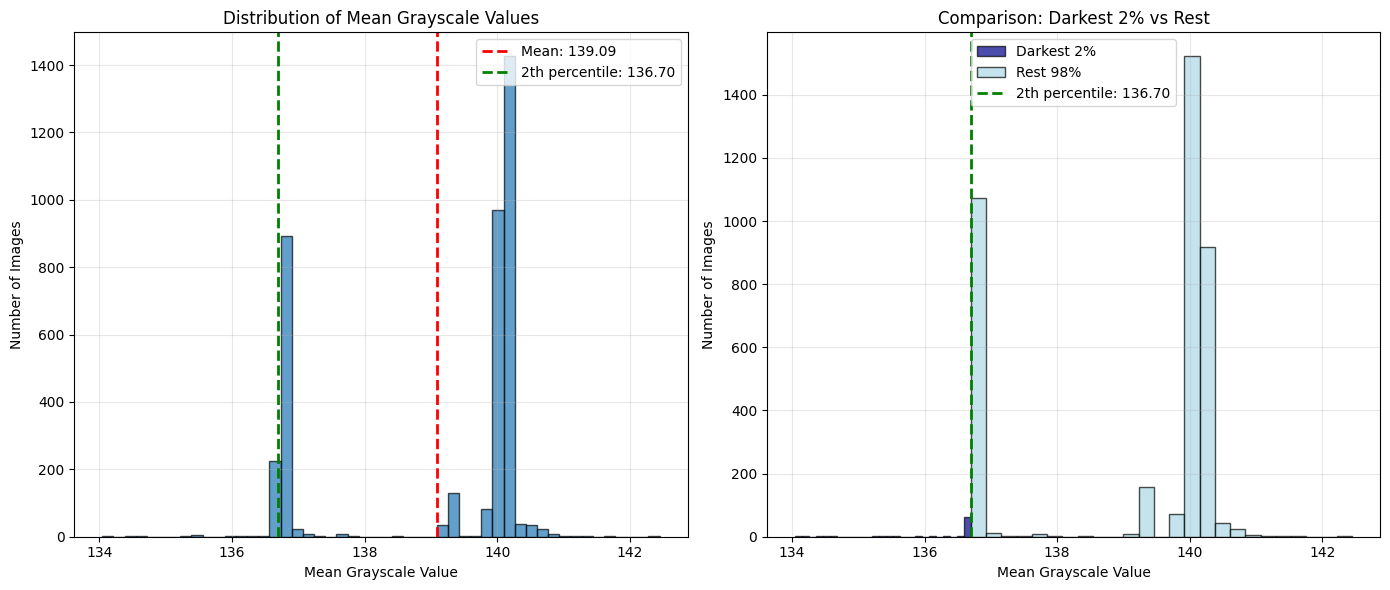


Summary Statistics:
  Total Images: 3938
  Overall Mean: 139.09
  2th Percentile: 136.70
  Min Value: 134.04
  Max Value: 142.45
  Std Dev: 1.53

  Darkest 2% Images: 79
  Mean of darkest 2%: 136.40


In [ ]:
import matplotlib.pyplot as plt

# Calculate statistics
overall_mean = np.mean(list(mean_values.values()))
percentile_threshold = np.percentile(list(mean_values.values()), DARKEST_PERCENTILE)

# Create histogram of mean grayscale values
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.hist(list(mean_values.values()), bins=50, edgecolor='black', alpha=0.7)
plt.axvline(overall_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {overall_mean:.2f}')
plt.axvline(percentile_threshold, color='green', linestyle='--', linewidth=2, label=f'{DARKEST_PERCENTILE}th percentile: {percentile_threshold:.2f}')
plt.xlabel('Mean Grayscale Value')
plt.ylabel('Number of Images')
plt.title('Distribution of Mean Grayscale Values')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Separate darkest and rest of images
darkest_vals = list(darker_images.values())
rest_vals = [v for k, v in mean_values.items() if k not in darker_images]

plt.hist(darkest_vals, bins=25, edgecolor='black', alpha=0.7, label=f'Darkest {DARKEST_PERCENTILE}%', color='darkblue')
plt.hist(rest_vals, bins=25, edgecolor='black', alpha=0.7, label=f'Rest {100-DARKEST_PERCENTILE}%', color='lightblue')
plt.axvline(percentile_threshold, color='green', linestyle='--', linewidth=2, label=f'{DARKEST_PERCENTILE}th percentile: {percentile_threshold:.2f}')
plt.xlabel('Mean Grayscale Value')
plt.ylabel('Number of Images')
plt.title(f'Comparison: Darkest {DARKEST_PERCENTILE}% vs Rest')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSummary Statistics:")
print(f"  Total Images: {len(mean_values)}")
print(f"  Overall Mean: {overall_mean:.2f}")
print(f"  {DARKEST_PERCENTILE}th Percentile: {percentile_threshold:.2f}")
print(f"  Min Value: {min(mean_values.values()):.2f}")
print(f"  Max Value: {max(mean_values.values()):.2f}")
print(f"  Std Dev: {np.std(list(mean_values.values())):.2f}")
print(f"\n  Darkest {DARKEST_PERCENTILE}% Images: {len(darker_images)}")
print(f"  Mean of darkest {DARKEST_PERCENTILE}%: {np.mean(list(darker_images.values())):.2f}")